# Quantum-Gated Cardiovascular Disease Classification

Adaptation of the same training configuration used for the previous Heart Disease dataset.

**Configuration:** 70/15/15 split, batch size 32, learning rate 5e-4, 100 max epochs, patience 10, Adam, CrossEntropyLoss, 256 hidden features, 2 qubits, 2 quantum layers, seed 42, StandardScaler.


In [1]:
%pip install -q pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 84.1 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 67.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 49.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 88.4 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import time
import random
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import pennylane as qml

SEED = 42
BATCH_SIZE = 32
NUM_WORKERS = 2
FULL_EPOCHS = 100
LR = 5e-4
PATIENCE = 10
N_QUBITS = 2
N_QLAYERS = 2
HIDDEN_FEATURES = 256

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)


Device: cuda
GPU: Tesla T4


In [3]:
# Find the CSV path
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))


/kaggle/input/datasets/sulianova/cardiovascular-disease-dataset/cardio_train.csv


In [5]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for file in files:
        print("   ", file)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/sulianova
/kaggle/input/datasets/sulianova/cardiovascular-disease-dataset
    cardio_train.csv


In [6]:
# Update this path if the previous cell printed a different path.
CSV_PATH = "/kaggle/input/datasets/sulianova/cardiovascular-disease-dataset/cardio_train.csv"

df = pd.read_csv(CSV_PATH, sep=";")

print("Dataset shape:", df.shape)
display(df.head())
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())


Dataset shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0



Columns: ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

Missing values:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


In [7]:
FEATURE_COLUMNS = [
    "age", "gender", "height", "weight", "ap_hi", "ap_lo",
    "cholesterol", "gluc", "smoke", "alco", "active"
]
TARGET_COLUMN = "cardio"

missing_columns = set(FEATURE_COLUMNS + [TARGET_COLUMN]) - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

X = df[FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df[TARGET_COLUMN], errors="coerce")

X = X.fillna(X.median())
if y.isnull().any():
    raise ValueError("Target contains missing values.")

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())


Input shape: (70000, 11)
Target shape: (70000,)

Target distribution:
cardio
0    35021
1    34979
Name: count, dtype: int64


In [8]:
X = X.values.astype(np.float32)
y = y.values.astype(np.int64)

indices = np.arange(len(X))
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

train_end = int(0.70 * len(indices))
val_end = int(0.85 * len(indices))

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))


Train: 49000
Validation: 10500
Test: 10500


In [9]:
# Fit scaler only on training data to avoid data leakage
scaler = StandardScaler()

X_train = scaler.fit_transform(X[train_idx])
X_val = scaler.transform(X[val_idx])
X_test = scaler.transform(X[test_idx])

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


In [10]:
class CardiovascularDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CardiovascularDataset(X_train, y_train)
val_dataset = CardiovascularDataset(X_val, y_val)
test_dataset = CardiovascularDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"))

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Train batches: 1532
Validation batches: 329
Test batches: 329


In [11]:

q_device = qml.device("default.qubit", wires=N_QUBITS)

def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

qnode = qml.QNode(
    quantum_circuit,
    q_device,
    interface="torch",
    diff_method="backprop"
)

weight_shapes = {"weights": (N_QLAYERS, N_QUBITS)}

def make_quantum_layer():
    return qml.qnn.TorchLayer(qnode, weight_shapes)


In [12]:
class QuantumGatedCardioModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Linear(11, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, HIDDEN_FEATURES),
            nn.BatchNorm1d(HIDDEN_FEATURES),
            nn.ReLU()
        )

        self.squeeze = nn.Sequential(
            nn.Linear(HIDDEN_FEATURES, 32),
            nn.ReLU(),
            nn.Linear(32, N_QUBITS),
            nn.Tanh()
        )

        self.quantum = make_quantum_layer()

        self.excite = nn.Sequential(
            nn.Linear(N_QUBITS, HIDDEN_FEATURES),
            nn.Sigmoid()
        )

        self.classifier = nn.Sequential(
            nn.Linear(HIDDEN_FEATURES, 128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.feature_extractor(x)

        q_input = self.squeeze(x) * np.pi

        q_output = self.quantum(
            q_input.to(device="cpu", dtype=torch.float32)
        )

        q_output = q_output.to(device=x.device, dtype=x.dtype)

        gate = self.excite(q_output)
        x = x * gate

        return self.classifier(x)

model = QuantumGatedCardioModel().to(DEVICE)
print(model)

dummy = torch.randn(4, 11).to(DEVICE)
print("Output shape:", model(dummy).shape)


QuantumGatedCardioModel(
  (feature_extractor): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
  )
  (squeeze): Sequential(
    (0): Linear(in_features=256, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
    (3): Tanh()
  )
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (excite): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): Sigmoid()
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)
Output

In [13]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_probs = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        running_loss += loss.item() * X_batch.size(0)

        probs = F.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.array(all_labels)
    predictions = all_probs.argmax(axis=1)

    metrics = {
        "loss": running_loss / len(loader.dataset),
        "accuracy": accuracy_score(all_labels, predictions),
        "precision": precision_score(all_labels, predictions, zero_division=0),
        "recall": recall_score(all_labels, predictions, zero_division=0),
        "f1": f1_score(all_labels, predictions, zero_division=0),
        "auc": roc_auc_score(all_labels, all_probs[:, 1])
    }

    return metrics, all_probs, all_labels


In [14]:
def run_training(model, train_loader, val_loader, epochs=100, lr=5e-4, patience=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "val_auc": []
    }

    best_f1 = -float("inf")
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(epochs):
        start_time = time.time()

        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion
        )

        val_metrics, _, _ = evaluate(
            model, val_loader, criterion
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_precision"].append(val_metrics["precision"])
        history["val_recall"].append(val_metrics["recall"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_auc"].append(val_metrics["auc"])

        current_f1 = val_metrics["f1"]

        if current_f1 > best_f1 + 1e-4:
            best_f1 = current_f1
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            best_epoch = epoch + 1
            epochs_without_improvement = 0
            status = " <-- BEST"
        else:
            epochs_without_improvement += 1
            status = ""

        elapsed = time.time() - start_time

        print(
            f"Epoch {epoch+1:03d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f} | "
            f"Val Precision: {val_metrics['precision']:.4f} | "
            f"Val Recall: {val_metrics['recall']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f} | "
            f"Val AUC: {val_metrics['auc']:.4f} | "
            f"{elapsed:.1f}s{status}"
        )

        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}.")
            print(f"Best epoch: {best_epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    # Expose the selected checkpoint metadata for deployment only.
    model.best_epoch = best_epoch
    model.best_validation_f1 = best_f1
    return model, history


In [15]:
# Train
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

model = QuantumGatedCardioModel().to(DEVICE)

model, history = run_training(
    model,
    train_loader,
    val_loader,
    epochs=FULL_EPOCHS,
    lr=LR,
    patience=PATIENCE
)


Epoch 001/100 | Train Loss: 0.6058 | Val Loss: 0.5635 | Val Acc: 0.7189 | Val Precision: 0.7283 | Val Recall: 0.7057 | Val F1: 0.7168 | Val AUC: 0.7845 | 24.2s <-- BEST
Epoch 002/100 | Train Loss: 0.5740 | Val Loss: 0.5504 | Val Acc: 0.7310 | Val Precision: 0.7369 | Val Recall: 0.7257 | Val F1: 0.7313 | Val AUC: 0.7972 | 24.2s <-- BEST
Epoch 003/100 | Train Loss: 0.5633 | Val Loss: 0.5655 | Val Acc: 0.7314 | Val Precision: 0.7454 | Val Recall: 0.7097 | Val F1: 0.7271 | Val AUC: 0.7954 | 24.4s
Epoch 004/100 | Train Loss: 0.5589 | Val Loss: 0.5602 | Val Acc: 0.7267 | Val Precision: 0.7591 | Val Recall: 0.6708 | Val F1: 0.7122 | Val AUC: 0.7938 | 23.4s
Epoch 005/100 | Train Loss: 0.5577 | Val Loss: 0.5471 | Val Acc: 0.7337 | Val Precision: 0.7382 | Val Recall: 0.7312 | Val F1: 0.7347 | Val AUC: 0.8026 | 23.5s <-- BEST
Epoch 006/100 | Train Loss: 0.5578 | Val Loss: 0.5437 | Val Acc: 0.7334 | Val Precision: 0.7430 | Val Recall: 0.7204 | Val F1: 0.7316 | Val AUC: 0.8015 | 24.3s
Epoch 007/100

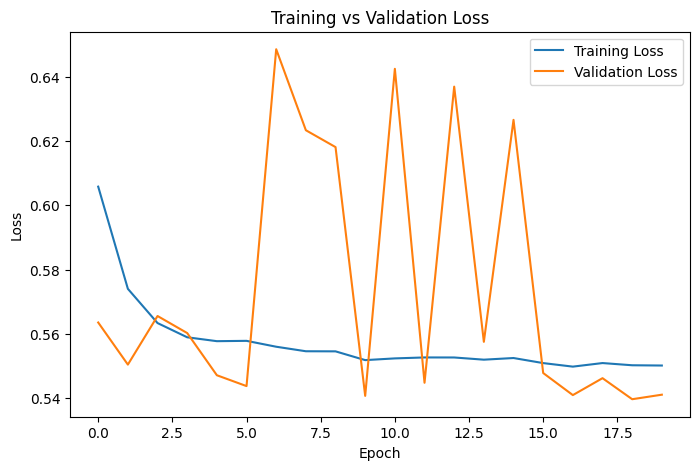

In [16]:
# Training curves
history_df = pd.DataFrame(history)

plt.figure(figsize=(8, 5))
plt.plot(history_df["train_loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


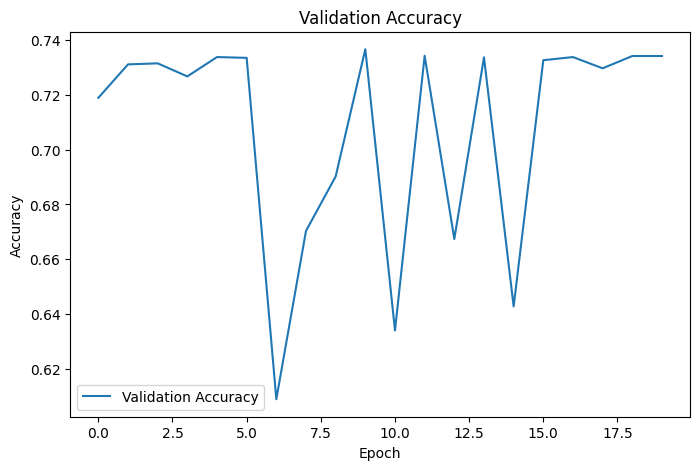

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.show()


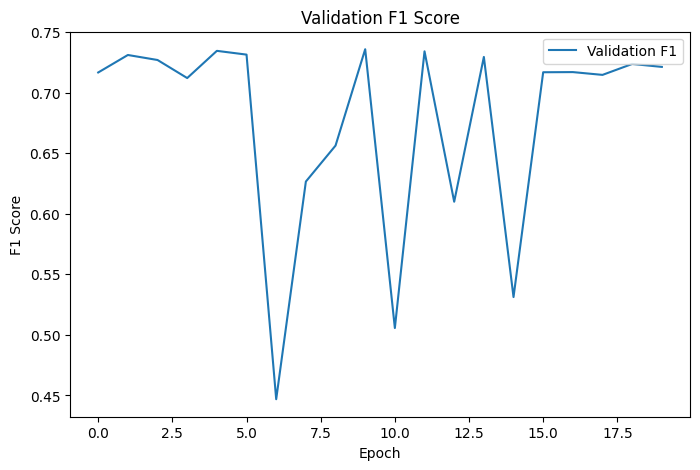

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["val_f1"], label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Validation F1 Score")
plt.legend()
plt.show()


In [19]:
# Final test metrics
criterion = nn.CrossEntropyLoss()

test_metrics, test_probs, test_labels = evaluate(
    model,
    test_loader,
    criterion
)

print("\n" + "=" * 55)
print("FINAL TEST METRICS")
print("=" * 55)
print(f"Accuracy  : {test_metrics['accuracy']:.4f}")
print(f"Precision : {test_metrics['precision']:.4f}")
print(f"Recall    : {test_metrics['recall']:.4f}")
print(f"F1 Score  : {test_metrics['f1']:.4f}")
print(f"AUC       : {test_metrics['auc']:.4f}")
print("=" * 55)



FINAL TEST METRICS
Accuracy  : 0.7377
Precision : 0.7395
Recall    : 0.7232
F1 Score  : 0.7313
AUC       : 0.8022


In [20]:
# Classification report
test_predictions = test_probs.argmax(axis=1)

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=[
            "No Cardiovascular Disease",
            "Cardiovascular Disease"
        ],
        digits=4
    )
)


                           precision    recall  f1-score   support

No Cardiovascular Disease     0.7361    0.7518    0.7439      5319
   Cardiovascular Disease     0.7395    0.7232    0.7313      5181

                 accuracy                         0.7377     10500
                macro avg     0.7378    0.7375    0.7376     10500
             weighted avg     0.7378    0.7377    0.7376     10500



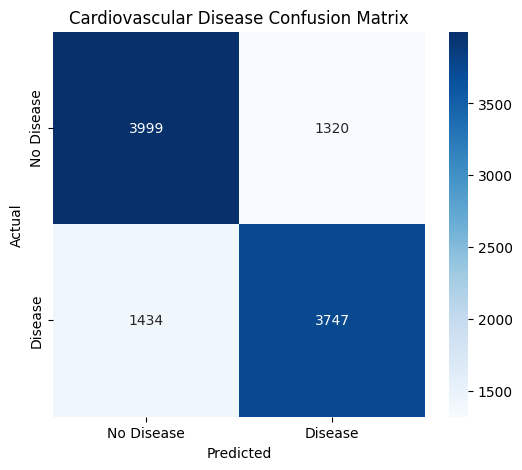

In [21]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Cardiovascular Disease Confusion Matrix")
plt.show()


In [ ]:
# Export the restored best-validation model and exact preprocessing dependencies.
import shutil
from pathlib import Path
from IPython.display import FileLink, display

DEPLOY_DIR = Path("/kaggle/working/cardiovascular_quantum_backend_model")
DEPLOY_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = DEPLOY_DIR / "cardiovascular_quantum_model.pth"
SCALER_PATH = DEPLOY_DIR / "cardiovascular_quantum_scaler.pkl"
CONFIG_PATH = DEPLOY_DIR / "cardiovascular_quantum_config.json"
ZIP_PATH = Path("/kaggle/working/cardiovascular_quantum_backend_model.zip")

# model was restored from best_state by run_training before it was returned.
torch.save(model.state_dict(), MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

# This exactly reproduces cell 6's numeric coercion and pre-split median fill.
imputation_medians = (
    df.loc[:, FEATURE_COLUMNS]
    .apply(pd.to_numeric, errors="coerce")
    .median()
    .to_dict()
)
imputation_medians = {
    column: float(imputation_medians[column]) for column in FEATURE_COLUMNS
}

config = {
    "model_name": "QuantumGatedCardioModel",
    "architecture": {
        "feature_extractor": "Linear(11,128) -> BatchNorm1d(128) -> ReLU -> Dropout(0.20) -> Linear(128,256) -> BatchNorm1d(256) -> ReLU",
        "hidden_features": HIDDEN_FEATURES,
        "quantum_squeeze": "Linear(256,32) -> ReLU -> Linear(32,2) -> Tanh -> multiply by pi",
        "quantum_gate": "Linear(2,256) -> Sigmoid -> element-wise multiply",
        "classifier": "Linear(256,128) -> ReLU -> Dropout(0.20) -> Linear(128,2)",
    },
    "feature_columns": FEATURE_COLUMNS,
    "target": TARGET_COLUMN,
    "input_dimension": len(FEATURE_COLUMNS),
    "num_classes": 2,
    "class_mapping": {
        "0": "No Cardiovascular Disease",
        "1": "Cardiovascular Disease",
    },
    "scaler_type": "StandardScaler",
    "preprocessing": {
        "numeric_conversion": "pd.to_numeric(errors='coerce')",
        "missing_value_imputation": "per-feature median computed from the full dataset before splitting",
        "median_imputation_values": imputation_medians,
        "age_preprocessing": "No age unit conversion; age is numeric-coerced and median-imputed only.",
    },
    "hidden_features": HIDDEN_FEATURES,
    "dropout": 0.20,
    "n_qubits": N_QUBITS,
    "n_quantum_layers": N_QLAYERS,
    "pennylane_device": "default.qubit",
    "quantum_embedding": "qml.AngleEmbedding",
    "quantum_layer_type": "qml.BasicEntanglerLayers with PauliZ expectation values",
    "seed": SEED,
    "split": "seeded shuffled row indices 70/15/15",
    "output": "raw two-class logits",
    "probability_operation": "softmax",
    "best_epoch": model.best_epoch,
    "best_validation_f1": model.best_validation_f1,
    "pytorch_version": torch.__version__,
    "pennylane_version": qml.__version__,
}
CONFIG_PATH.write_text(json.dumps(config, indent=2), encoding="utf-8")

if ZIP_PATH.exists():
    ZIP_PATH.unlink()
shutil.make_archive(
    str(ZIP_PATH.with_suffix("")),
    "zip",
    root_dir=DEPLOY_DIR.parent,
    base_dir=DEPLOY_DIR.name,
)

print("Deployment files:")
for path in (MODEL_PATH, SCALER_PATH, CONFIG_PATH, ZIP_PATH):
    print(path.resolve())
print(f"Download this ZIP from Kaggle: {ZIP_PATH.resolve()}")
display(FileLink(ZIP_PATH, result_html_prefix="Kaggle download link: "))

# Fresh-load backend simulation: CPU weights, scaler, config, and raw input.
reloaded_config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
reloaded_scaler = joblib.load(SCALER_PATH)
reloaded_model = QuantumGatedCardioModel()
reloaded_model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
reloaded_model.eval()

raw_sample = df.iloc[[0]].copy()
sample_features = raw_sample.loc[:, reloaded_config["feature_columns"]]
sample_features = sample_features.apply(pd.to_numeric, errors="coerce")
sample_features = sample_features.fillna(
    pd.Series(reloaded_config["preprocessing"]["median_imputation_values"])
)
sample_features = sample_features.loc[:, reloaded_config["feature_columns"]]
scaled_sample = reloaded_scaler.transform(
    sample_features.to_numpy(dtype=np.float32)
).astype(np.float32)
sample_tensor_cpu = torch.from_numpy(scaled_sample).to(dtype=torch.float32)

model.eval()
with torch.no_grad():
    original_logits = model(sample_tensor_cpu.to(DEVICE)).cpu()
    reloaded_logits = reloaded_model(sample_tensor_cpu)
    probabilities = torch.softmax(reloaded_logits, dim=1)

np.testing.assert_allclose(
    original_logits.numpy(), reloaded_logits.numpy(), rtol=1e-5, atol=1e-6
)
predicted_class = int(probabilities.argmax(dim=1).item())
print("Smoke test passed: reloaded CPU model matches the restored best model.")
print("Predicted class:", predicted_class)
print("No Cardiovascular Disease probability:", float(probabilities[0, 0]))
print("Cardiovascular Disease probability:", float(probabilities[0, 1]))
